In [2]:
!pip install setfit datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.7/42.7 MB 145.2 MB/s  0:00:00m0:00:01
  Attempting uninstall: dill━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/7 [pyarrow]
    Found existing installation: dill 0.4.1━━━━━━━━━━━━━━━━━━━ 1/7 [pyarrow]
    Uninstalling dill-0.4.1:━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/7 [pyarrow]
      Successfully uninstalled dill-0.4.1━━━━━━━━━━━━━━━━━━━━━ 1/7 [pyarrow]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [setfit]2m6/7 [setfit]e]ess]

[notice] A new release of pip is available: 20.0.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [50]:
import pandas as pd
import numpy as np
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support, log_loss 
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

In [2]:
train_df = pd.read_csv('train_stance.csv', index_col=0)
test_df = pd.read_csv('test_stance.csv', index_col=0)

In [3]:
train_df

,text,claim_labels,stance,confidence,topic_title
0,"Of course, we have to improve the system, but ...",230,against,0.853987,Immigration
1,I think this is partly what's been going wrong...,230,against,0.661541,Immigration
2,No. I want to be a member of the European Unio...,1910,support,0.827143,"Western Europe, Common Market Issues"
3,Well it depends whether you're talking about t...,107,neutral,0.590986,"Taxation, Tax policy, and Tax Reform"
4,But you are right when you say that you can't ...,230,against,0.695967,Immigration
...,...,...,...,...,...
4117,"Terry, like so many people around the country,...",107,support,0.615345,"Taxation, Tax policy, and Tax Reform"
4118,"Terry, like so many people around the country,...",325,support,0.860713,Health Manpower and Training
4119,"Yeah, I was incredibly sad to have caused peop...",1609,support,0.951787,Veterans Issues
4120,There are lots of people who go for private he...,108,support,0.614357,"Industrial Policy, Privatisation, Nationalisation"


In [4]:
test_df

,ID,text,claim_labels,stance,topic_title
0,0,"So knife crime's going to go up, because the e...",1211,support,Riots and Crime Prevention
1,1,Of course Gordon Brown's right to say there's ...,107,against,"Taxation, Tax policy, and Tax Reform"
2,1,Of course Gordon Brown's right to say there's ...,1302,support,Poverty and Assistance for Low-Income Families
3,1,Of course Gordon Brown's right to say there's ...,602,support,Elementary and Secondary Education
4,1,Of course Gordon Brown's right to say there's ...,603,support,Education of Underprivileged Students
...,...,...,...,...,...
534,2601,"Well, I share the frustration of both our ques...",202,support,Gender and Sexual Orientation Discrimination
535,2601,"Well, I share the frustration of both our ques...",230,neutral,Immigration
536,3070,You're saying people voted for 10% tariffs on ...,1006,support,Truck and Automobile Transportation and Safety
537,3356,I think this question of enthusiasm is really ...,2032,support,Prime Ministerial or Ministerial Scandals and ...


In [5]:
label_map = {"support": 0, "against": 1, "neutral": 2}
train_df["label"] = train_df["stance"].map(label_map)
test_df["label"] = test_df["stance"].map(label_map)

In [6]:
test_df

,ID,text,claim_labels,stance,topic_title,label
0,0,"So knife crime's going to go up, because the e...",1211,support,Riots and Crime Prevention,0.0
1,1,Of course Gordon Brown's right to say there's ...,107,against,"Taxation, Tax policy, and Tax Reform",1.0
2,1,Of course Gordon Brown's right to say there's ...,1302,support,Poverty and Assistance for Low-Income Families,0.0
3,1,Of course Gordon Brown's right to say there's ...,602,support,Elementary and Secondary Education,0.0
4,1,Of course Gordon Brown's right to say there's ...,603,support,Education of Underprivileged Students,0.0
...,...,...,...,...,...,...
534,2601,"Well, I share the frustration of both our ques...",202,support,Gender and Sexual Orientation Discrimination,0.0
535,2601,"Well, I share the frustration of both our ques...",230,neutral,Immigration,2.0
536,3070,You're saying people voted for 10% tariffs on ...,1006,support,Truck and Automobile Transportation and Safety,0.0
537,3356,I think this question of enthusiasm is really ...,2032,support,Prime Ministerial or Ministerial Scandals and ...,0.0


In [7]:
for index, row in test_df.iterrows():
    if row['label'] not in [1.0, 2.0, 0.0]:
        print(f"{row['stance']}---{row['label']}")

against                         ---nan
against  ---nan
against ---nan
against ---nan
against ---nan
against ---nan
against ---nan
against ---nan
against ---nan
against ---nan
support ---nan
support ---nan
support ---nan
against ---nan
support ---nan
against ---nan
support ---nan
against ---nan
against ---nan
against ---nan
against ---nan
against ---nan
against ---nan
against ---nan
against ---nan
support ---nan
support ---nan
support ---nan
against ---nan
support ---nan
against ---nan
against ---nan
against ---nan
support ---nan
support ---nan
support ---nan
against ---nan
support ---nan
support ---nan
against  ---nan


In [8]:
for index, row in test_df.iterrows():
    if row['stance'] not in ['support', 'against', 'neutral']:
        print(row['stance'])

against                         
against  
against 
against 
against 
against 
against 
against 
against 
against 
support 
support 
support 
against 
support 
against 
support 
against 
against 
against 
against 
against 
against 
against 
against 
support 
support 
support 
against 
support 
against 
against 
against 
support 
support 
support 
against 
support 
support 
against  


In [9]:
def fix_stances(stance):
    if 'support' in stance:
        return 'support'
    elif 'against' in stance:
        return 'against'
    elif 'neutral' in stance:
        return 'neutral'    

In [10]:
test_df['stance'] = test_df['stance'].apply(fix_stances)

In [11]:
for index, row in test_df.iterrows():
    if row['stance'] not in ['support', 'against', 'neutral']:
        print(row['stance'])

In [12]:
test_df["label"] = test_df["stance"].map(label_map)

In [13]:
for index, row in test_df.iterrows():
    if row['label'] not in [0, 1, 2]:
        print(f"{row['stance']}---{row['label']}")
        
for index, row in train_df.iterrows():
    if row['label'] not in [0, 1, 2]:
        print(f"{row['stance']}---{row['label']}")        

In [14]:
train_df

,text,claim_labels,stance,confidence,topic_title,label
0,"Of course, we have to improve the system, but ...",230,against,0.853987,Immigration,1
1,I think this is partly what's been going wrong...,230,against,0.661541,Immigration,1
2,No. I want to be a member of the European Unio...,1910,support,0.827143,"Western Europe, Common Market Issues",0
3,Well it depends whether you're talking about t...,107,neutral,0.590986,"Taxation, Tax policy, and Tax Reform",2
4,But you are right when you say that you can't ...,230,against,0.695967,Immigration,1
...,...,...,...,...,...,...
4117,"Terry, like so many people around the country,...",107,support,0.615345,"Taxation, Tax policy, and Tax Reform",0
4118,"Terry, like so many people around the country,...",325,support,0.860713,Health Manpower and Training,0
4119,"Yeah, I was incredibly sad to have caused peop...",1609,support,0.951787,Veterans Issues,0
4120,There are lots of people who go for private he...,108,support,0.614357,"Industrial Policy, Privatisation, Nationalisation",0


In [15]:
test_df

,ID,text,claim_labels,stance,topic_title,label
0,0,"So knife crime's going to go up, because the e...",1211,support,Riots and Crime Prevention,0
1,1,Of course Gordon Brown's right to say there's ...,107,against,"Taxation, Tax policy, and Tax Reform",1
2,1,Of course Gordon Brown's right to say there's ...,1302,support,Poverty and Assistance for Low-Income Families,0
3,1,Of course Gordon Brown's right to say there's ...,602,support,Elementary and Secondary Education,0
4,1,Of course Gordon Brown's right to say there's ...,603,support,Education of Underprivileged Students,0
...,...,...,...,...,...,...
534,2601,"Well, I share the frustration of both our ques...",202,support,Gender and Sexual Orientation Discrimination,0
535,2601,"Well, I share the frustration of both our ques...",230,neutral,Immigration,2
536,3070,You're saying people voted for 10% tariffs on ...,1006,support,Truck and Automobile Transportation and Safety,0
537,3356,I think this question of enthusiasm is really ...,2032,support,Prime Ministerial or Ministerial Scandals and ...,0


In [16]:
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

In [17]:
model_name = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [22]:
model_name = "microsoft/deberta-v3-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

/home2/pwfb75/joel_jupyterenv-3.9/lib/python3.9/site-packages/transformers/convert_slow_tokenizer.py:566: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


In [23]:
def preprocess(example):
    return tokenizer(
        example["text"],
        example["topic_title"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

In [18]:
def preprocess_no_topic(example):
    return tokenizer(
        example["text"],
        example["topic_title"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

In [24]:
train_dataset = train_dataset.map(preprocess, batched=True)
test_dataset = test_dataset.map(preprocess, batched=True)

Map:   0%|          | 0/3337 [00:00<?, ? examples/s]

Map:   0%|          | 0/537 [00:00<?, ? examples/s]

In [19]:
train_dataset = train_dataset.map(preprocess_no_topic, batched=True)
test_dataset = test_dataset.map(preprocess_no_topic, batched=True)

Map:   0%|          | 0/3337 [00:00<?, ? examples/s]

Map:   0%|          | 0/537 [00:00<?, ? examples/s]

In [20]:
train_dataset

Dataset({
    features: ['text', 'claim_labels', 'stance', 'confidence', 'topic_title', 'label', '__index_level_0__', 'input_ids', 'attention_mask'],
    num_rows: 3337
})

In [21]:
test_dataset

Dataset({
    features: ['ID', 'text', 'claim_labels', 'stance', 'topic_title', 'label', '__index_level_0__', 'input_ids', 'attention_mask'],
    num_rows: 537
})

In [22]:
train_dataset = train_dataset.remove_columns(["text", "topic_title", "stance"])

In [23]:
train_dataset = train_dataset.remove_columns(["claim_labels", "confidence", "__index_level_0__"])


In [24]:
test_dataset = test_dataset.remove_columns(["ID", "claim_labels", "text", "__index_level_0__", "topic_title", "stance"])

In [26]:
test_dataset

Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 537
})

In [32]:
test_dataset = test_dataset.remove_columns(["token_type_ids"])
train_dataset = train_dataset.remove_columns(["token_type_ids"])

In [34]:
test_dataset

Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 537
})

In [27]:
train_dataset.set_format("torch")
test_dataset.set_format("torch")

In [28]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3
)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [29]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    precision, recall, f1, _  = precision_recall_fscore_support(
            labels, preds, average="macro", zero_division=0)
    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision,
        "recall": recall,
        "macro_f1": f1        
    }


In [30]:
training_args = TrainingArguments(
    output_dir="./stance_model",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    
    num_train_epochs=5,
    weight_decay=0.01,
    
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    
    warmup_ratio=0.1,
    lr_scheduler_type="linear",
    
    fp16=True, 
    save_total_limit=2
)

In [31]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

Detected kernel version 5.4.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


In [41]:
# DeBERTa
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,Macro F1
1,0.756700,0.824855,0.670391,0.421788,0.469235,0.444172
2,0.575100,0.841499,0.621974,0.410659,0.463117,0.423209
3,0.478000,0.966981,0.644320,0.408258,0.459545,0.429220
4,0.382900,1.138719,0.651769,0.406161,0.453485,0.428049
5,0.285700,1.288776,0.664804,0.748843,0.475866,0.462094


TrainOutput(global_step=2090, training_loss=0.4956708588668604, metrics={'train_runtime': 561.5756, 'train_samples_per_second': 29.711, 'train_steps_per_second': 3.722, 'total_flos': 2195063052249600.0, 'train_loss': 0.4956708588668604, 'epoch': 5.0})

In [33]:
# RoBERTa no topic
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,Macro F1
1,0.298300,1.408341,0.675978,0.728691,0.553912,0.590623
2,0.291900,1.471800,0.672253,0.615688,0.572572,0.587333
3,0.200300,1.848383,0.685289,0.727558,0.577858,0.610059
4,0.152900,2.046376,0.681564,0.723066,0.571338,0.605007
5,0.095600,2.107241,0.692737,0.729073,0.574046,0.610012


TrainOutput(global_step=2090, training_loss=0.20778843820380252, metrics={'train_runtime': 283.2783, 'train_samples_per_second': 58.9, 'train_steps_per_second': 7.378, 'total_flos': 2195023687395840.0, 'train_loss': 0.20778843820380252, 'epoch': 5.0})

In [54]:
# RoBERTa results
results = trainer.evaluate()
print(results)

{'eval_loss': 1.3657760620117188, 'eval_accuracy': 0.6871508379888268, 'eval_precision': 0.7422803835602738, 'eval_recall': 0.5766243213051724, 'eval_macro_f1': 0.6114531793866181, 'eval_runtime': 2.0491, 'eval_samples_per_second': 262.065, 'eval_steps_per_second': 16.593, 'epoch': 5.0}


In [42]:
# DeBERTa results
results = trainer.evaluate()
print(results)

{'eval_loss': 1.2887762784957886, 'eval_accuracy': 0.664804469273743, 'eval_precision': 0.7488431222984998, 'eval_recall': 0.47586574182318864, 'eval_macro_f1': 0.46209380395186245, 'eval_runtime': 4.5568, 'eval_samples_per_second': 117.847, 'eval_steps_per_second': 7.461, 'epoch': 5.0}


In [35]:
# RoBERTa no topic results
results = trainer.evaluate()
print(results)

{'eval_loss': 1.848382592201233, 'eval_accuracy': 0.6852886405959032, 'eval_precision': 0.7275582573454914, 'eval_recall': 0.5778583119008651, 'eval_macro_f1': 0.6100586696826182, 'eval_runtime': 1.9789, 'eval_samples_per_second': 271.356, 'eval_steps_per_second': 17.181, 'epoch': 5.0}


In [36]:
def plot_loss_curves(train_losses, eval_losses, name):    
    sns.set_style("whitegrid")
    
    plt.figure(figsize=(8, 5))
    
    plt.plot(train_losses, label='Train Loss', color='#2ecc71', marker='o') # Green
    plt.plot(eval_losses, label='Eval Loss', color='#e74c3c', marker='o')  # Red
    
    plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    
    plt.title('Training vs Evaluation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.savefig(f"{name}_loss_plot.png")
    plt.show()
            

In [37]:
#For loss:
history = trainer.state.log_history
train_loss = [log['loss'] for log in history if 'loss' in log]
eval_loss = [log['eval_loss'] for log in history if 'eval_loss' in log]

In [ ]:
plot_loss_curves(train_loss, eval_loss, model_name)

In [4]:
train_losses = [0.436800, 0.416900, 0.328600, 0.245600, 0.166200]
eval_losses = [0.969489, 0.924542, 1.365776, 1.597856, 1.798108]

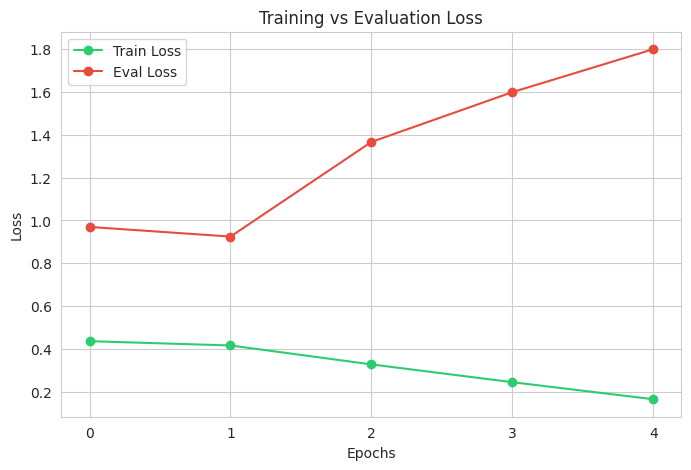

In [5]:
plot_loss_curves(train_losses,eval_losses,"roberta")

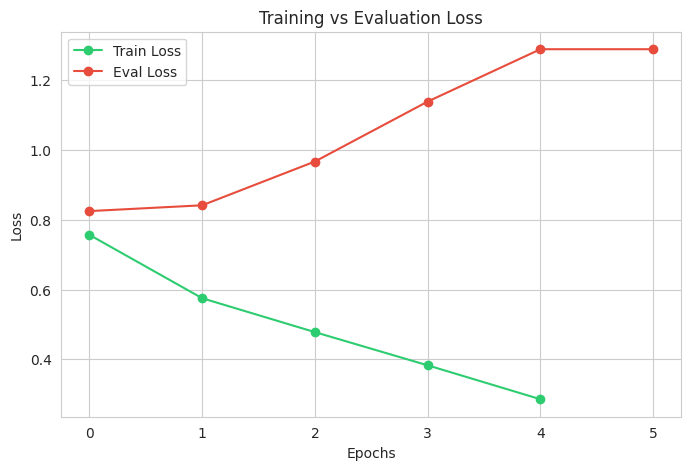

In [46]:
plot_loss_curves(train_loss, eval_loss, 'deberta')

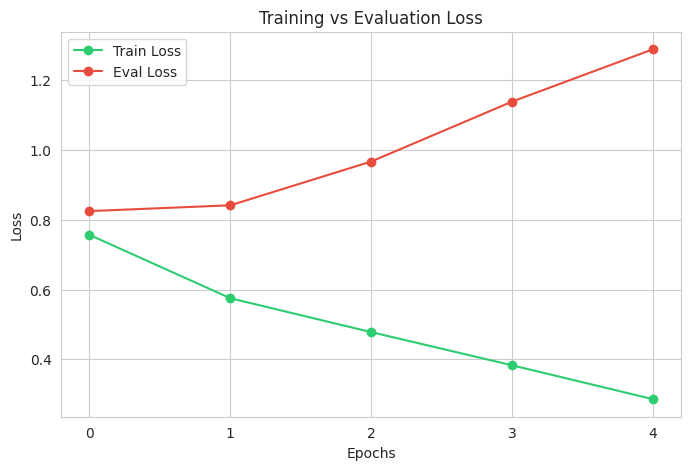

In [39]:
train_losses = [0.756700, 0.575100, 0.478000, 0.382900, 0.285700]
eval_losses = [0.824855, 0.841499, 0.966981, 1.138719, 1.288776]
plot_loss_curves(train_losses,eval_losses,"deberta_1")

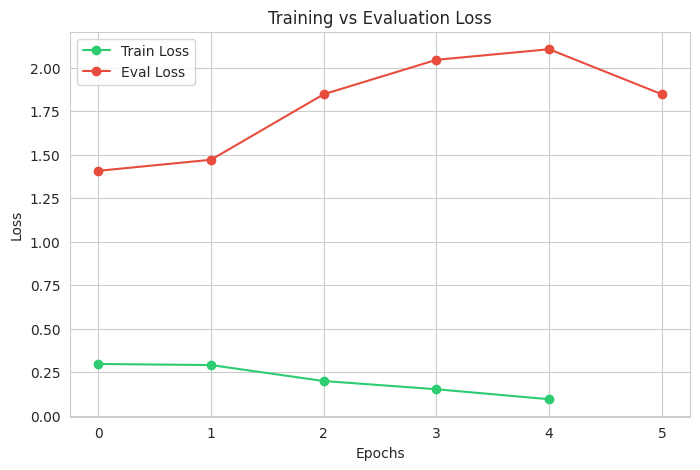

In [38]:
plot_loss_curves(train_loss, eval_loss, 'roberta_no_topic')

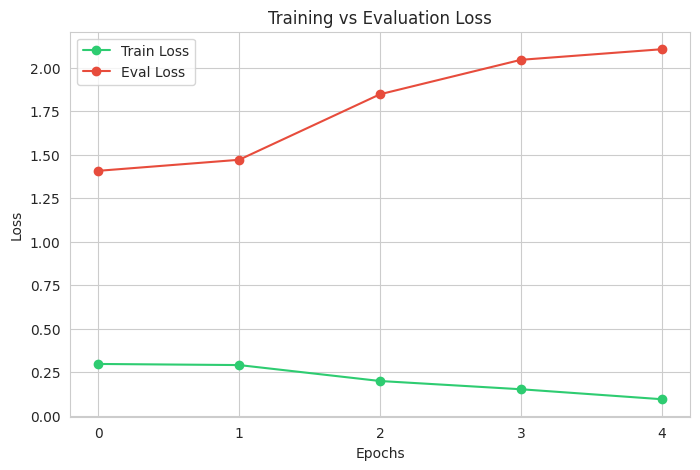

In [40]:
train_losses = [0.298300, 0.291900, 0.200300, 0.152900, 0.095600]
eval_losses = [1.408341, 1.471800, 1.848383, 2.046376, 2.107241]
plot_loss_curves(train_losses,eval_losses,"roberta_no_topic_1")

In [43]:
# TF-IDF to LR

train_text = train_df["text"] + " [SEP] " + train_df["topic_title"]
test_text = test_df["text"] + " [SEP] " + test_df["topic_title"]

In [44]:
y_train = train_df["label"]
y_test = test_df["label"]

In [46]:
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=20000,
        ngram_range=(1, 2),
        stop_words="english"
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

In [47]:
pipeline.fit(train_text, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=20000, ngram_range=(1, 2),
                                 stop_words='english')),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [48]:
y_pred = pipeline.predict(test_text)
y_proba = pipeline.predict_proba(test_text)

In [51]:
accuracy = accuracy_score(y_test, y_pred)

precision, recall, f1, _ = precision_recall_fscore_support(
    y_test, y_pred, average="macro"
)

print({
    "accuracy": accuracy,
    "precision": precision,
    "recall": recall,
    "macro_f1": f1
})

{'accuracy': 0.6256983240223464, 'precision': 0.6088033372930226, 'recall': 0.5155223027563453, 'macro_f1': 0.5222121981411157}


In [52]:
train_proba = pipeline.predict_proba(train_text)
test_proba = pipeline.predict_proba(test_text)

train_loss = log_loss(y_train, train_proba)
test_loss = log_loss(y_test, test_proba)

print({
    "train_loss": train_loss,
    "test_loss": test_loss
})

{'train_loss': 0.5042938924485615, 'test_loss': 0.8131659199828137}


In [1]:
print(3)

3
